# Scanning-tunnelling microscopy: an image of the states at one energy

A scanning-tunnelling microscope holds a sharp tip a few angstroms above a surface and
measures the current that tunnels across the gap. Tersoff and Hamann showed that for a
tip with no structure of its own the current is proportional to the sample's **local
density of states at the tip's position**, at the energy the bias selects:

$$ \rho_\mathrm{STM}(\mathbf r) \;=\; \sum_{n\mathbf k} w_{\mathbf k}\,
   \tilde\delta(E - \varepsilon_{n\mathbf k})\,|\psi_{n\mathbf k}(\mathbf r)|^2 . $$

So an STM image is not a picture of the atoms and it is not a picture of the charge. It
is a picture of the states within a narrow energy window of the Fermi level, evaluated
out in the vacuum where the tip sits. The difference between those three things is the
whole subject of this notebook, and bilayer graphite makes it as sharply as any crystal
can: **only half of its surface atoms show up.**

In [1]:
from pathlib import Path

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

def site(f1, f2, n):
    return int(round(f1 * n)) % n, int(round(f2 * n)) % n

graphite = Calculator.from_file(CASES / "graphene-bilayer.in", PSEUDO, announce=False)
image = graphite.get_stm(height=0.85, shape=(64, 64))

print(f"tunnelling density {image.values.min():.2e} to {image.values.max():.2e} per bohr^3 per Ry")
print(f"integrating it over the cell gives D(E_F) = {image.integral:.4f} states/Ry")

tunnelling density 5.38e-07 to 9.64e-04 per bohr^3 per Ry
integrating it over the cell gives D(E_F) = 2.4834 states/Ry


## Half the atoms are missing

Graphite stacks its layers so that half the atoms of the top layer sit directly above an
atom of the layer below, and the other half sit above the middle of a hexagon. Those two
sublattices are both carbon, they carry the same charge, and they sit in a perfectly
regular honeycomb. But they are not equivalent, because what is underneath them differs,
and the states right at the Fermi level notice.

The right panel is the other reason a microscope only ever sees the outermost layer: the
tunnelling density falls by an order of magnitude roughly every bohr and a quarter into
the vacuum, so a tip a few bohr out is reading the surface and nothing else.

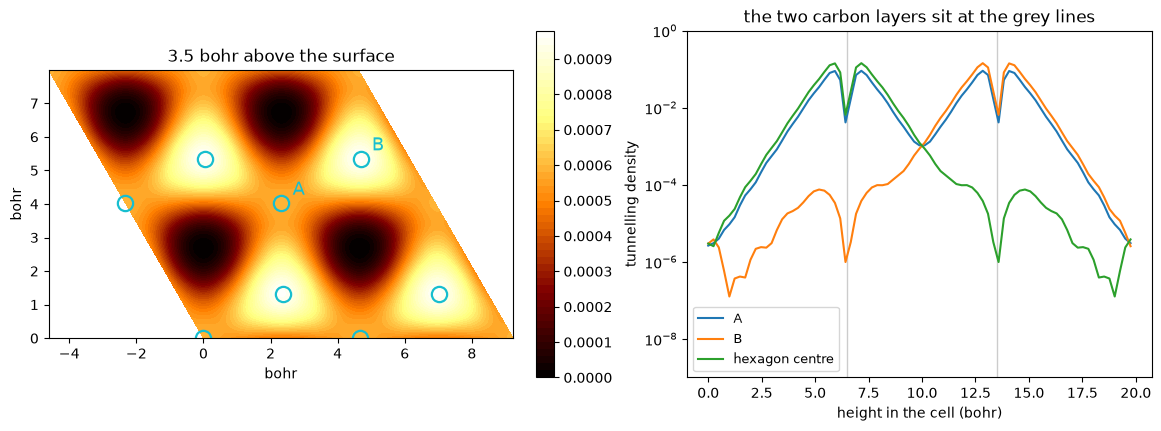

In [2]:
import matplotlib.pyplot as plt
import numpy as np

atoms = {"A (over an atom below)": (0.0, 0.0), "B (over a hollow)": (2 / 3, 1 / 3)}
field = np.asarray(image.density)
tall = float(np.asarray(graphite.system.cell.at)[2, 2])
height = np.arange(field.shape[2]) / field.shape[2] * tall
edges = 64 * (image.coordinates[[1, 0], [0, 1]] - image.coordinates[0, 0])
tiles = np.array([m * edges[0] + n * edges[1] for m in range(2) for n in range(2)])

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
spots = np.concatenate([image.coordinates.reshape(-1, 2) + t for t in tiles])
art = ax.tricontourf(spots[:, 0], spots[:, 1], np.tile(image.values.ravel(), 4), 60, cmap="afmhot")
for name, (f1, f2) in atoms.items():
    marks = image.coordinates[site(f1, f2, 64)] + tiles
    ax.plot(marks[:, 0], marks[:, 1], "o", mfc="none", mec="tab:cyan", ms=11, mew=1.6)
    ax.annotate(name[0], marks[-1], color="tab:cyan", fontsize=13, xytext=(8, 6),
                textcoords="offset points")
ax.set(title="3.5 bohr above the surface", xlabel="bohr", ylabel="bohr", aspect="equal")
fig.colorbar(art, ax=ax, fraction=0.05)

for name, (f1, f2) in {**atoms, "hexagon centre": (1 / 3, 2 / 3)}.items():
    bx.semilogy(height, field[site(f1, f2, field.shape[0])], label=name.split(" (")[0])
[bx.axvline(layer, color="0.8", lw=1, zorder=0) for layer in (6.5, 13.5)]
bx.set(xlabel="height in the cell (bohr)", ylabel="tunnelling density", ylim=(1e-9, 1),
       title="the two carbon layers sit at the grey lines")
bx.legend(fontsize=9)
plt.show()

Both panels say the same thing. A is the sublattice sitting over an atom of the layer
below and B is the one over a hollow, and B is the bright one. This is the classic result
that a topograph of graphite shows a **triangular** lattice where the crystal has a
honeycomb one, and it is the reason a beginner counting spots on a graphite image gets
the wrong structure.

In [3]:
bright = {name[0]: image.values[site(f1, f2, 64)] for name, (f1, f2) in atoms.items()}
hollow = image.values[site(1 / 3, 2 / 3, 64)]
print(f"A {bright['A']:.3e}    B {bright['B']:.3e}    B/A = {bright['B'] / bright['A']:.2f}")
print(f"hexagon centre {hollow:.3e}    A/centre = {bright['A'] / hollow:.0f}")

A 5.883e-04    B 9.642e-04    B/A = 1.64
hexagon centre 5.380e-07    A/centre = 1093


## The bias chooses which states are looked at

At zero bias the tip samples a narrow window at the Fermi level. Put a voltage across the
junction and the window opens: a positive sample bias lets electrons tunnel from the tip
into the **empty** states just above the Fermi level, and a negative one lets them come
out of the **filled** states just below it. The same surface can therefore look
different, and on some materials it inverts entirely.

In [4]:
for label, bias in (("filled (-2 eV)", -0.147), ("at E_F", None), ("empty (+2 eV)", +0.147)):
    picture = graphite.get_stm(height=0.85, shape=(64, 64), bias=bias)
    seen = {name[0]: picture.values[site(f1, f2, 64)] for name, (f1, f2) in atoms.items()}
    print(f"{label:15s}  A {seen['A']:.3e}   B {seen['B']:.3e}"
          f"   B/A = {seen['B'] / seen['A']:.2f}")

filled (-2 eV)   A 1.875e-04   B 2.006e-04   B/A = 1.07


at E_F           A 5.883e-04   B 9.642e-04   B/A = 1.64


empty (+2 eV)    A 2.764e-04   B 2.634e-04   B/A = 0.95


## A magnetic tip, and an image that depends on which way it points

If the tip is itself magnetic it does not count every state equally. It counts the ones
whose spin lies along its own moment, so the image becomes

$$ \rho_\mathrm{STM}(\mathbf r; \hat{\mathbf n}) \;=\;
   \tfrac12\left[\rho(\mathbf r) + \hat{\mathbf n}\cdot\mathbf m(\mathbf r)\right] $$

for a fully polarized tip pointing along $\hat{\mathbf n}$. This is how a surface magnetic
structure is read off directly, one atom at a time, and it is the only measurement that
can see an antiferromagnet whose atoms all carry the same charge.

The crystal below is a chain of four hydrogen atoms whose moments each turn 90 degrees
from the one before, so no single axis describes all four.

In [5]:
chain = Calculator.from_file(CASES / "h-chain-90deg.in", PSEUDO, announce=False)
side = dict(plane=((0.15, 0.0, 0.0), (0.15, 0.30, 0.0), (0.15, 0.0, 1.0)),
            shape=(4, 64), width=0.10)

charge = chain.get_stm(**side)
tips = {"x": (1, 0, 0), "y": (0, 1, 0), "z": (0, 0, 1)}
polarized = {name: chain.get_stm(spin=vector, **side) for name, vector in tips.items()}

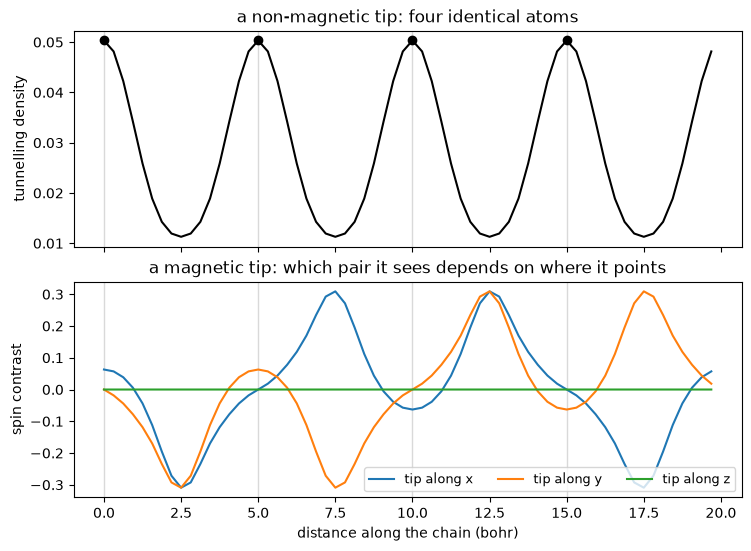

In [6]:
distance = charge.coordinates[0, :, 1]
sites = distance[::16]
fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.4, 5.4), sharex=True, layout="constrained")
ax.plot(distance, charge.values[0], "k")
ax.plot(sites, charge.values[0][::16], "ko")
ax.set(ylabel="tunnelling density", title="a non-magnetic tip: four identical atoms")
for name, picture in polarized.items():
    bx.plot(distance, (2 * picture.values[0] - charge.values[0]) / charge.values[0],
            label=f"tip along {name}")
for atom in sites:
    ax.axvline(atom, color="0.85", lw=1, zorder=0)
    bx.axvline(atom, color="0.85", lw=1, zorder=0)
bx.set(xlabel="distance along the chain (bohr)", ylabel="spin contrast",
       title="a magnetic tip: which pair it sees depends on where it points")
bx.legend(fontsize=9, ncol=3)
plt.show()

Every vertical line is an atom, and the upper panel is what a non-magnetic tip records:
four peaks of the same height, because the four atoms carry the same charge. A microscope
with a plain tip would report a chain of four identical atoms and miss the magnetism
entirely.

The lower panel is the same four atoms seen by a magnetic tip. **At the atoms**, a tip
along $x$ sees the first and third with opposite signs and the second and fourth not at
all, because their moments are at right angles to it; a tip along $y$ is that picture
shifted by one atom; and a tip along $z$ sees nothing anywhere, all four moments lying
flat. The structure in between the atoms is real and is not the moments: it is the spin
polarization of the states at the Fermi level, which need not point the same way as the
magnetization that produced them.

## Against Quantum ESPRESSO

QE computes the same quantity, and the comparison below is on every point of the grid of
its own aluminium benchmark rather than on a single number.

In [7]:
aluminium = Calculator.from_file(CASES / "al-metal.in", PSEUDO, announce=False)
ours = aluminium.get_stm(height=0.0, width=0.05, smearing="marzari-vanderbilt",
                         band_cutoff=3.0)

lines = (CASES / "reference.stm.al-metal").read_text().splitlines()
nx, ny, _, _, _, nz, nat, ntyp = (int(v) for v in lines[1].split())
theirs = np.array(" ".join(lines[4 + ntyp + nat:]).split(), dtype=float)
theirs = np.transpose(theirs[:nx * ny * nz].reshape((nz, ny, nx)), (2, 1, 0))

mine = np.asarray(ours.density) * ours.width
print(f"grid {theirs.shape}, values up to {theirs.max():.6f}")
print(f"largest difference anywhere: {np.abs(mine - theirs).max():.2e}")

grid (15, 15, 15), values up to 0.003401
largest difference anywhere: 6.66e-10


## What else is here

`get_stm` takes `plane=` for any plotting plane (three corners in crystal coordinates,
which is what the chain above uses), `grid=` to re-solve the bands on a denser k-mesh
before sampling the Fermi level, `smearing=` and `width=` for the shape of the energy
window, and `polarization=` for a tip that is not fully polarized.

`mode="constant-current"` returns the corrugation instead: the height the tip has to sit
at to hold the current fixed, which is what a microscope actually records. It wants a
cell with a generous vacuum gap, more than the benchmark above has, because the tip must
be able to withdraw far enough for the current to fall to the set-point everywhere,
including over the middle of a hexagon where it is four orders of magnitude down. Points
the set-point never reaches come back as `nan` rather than as a plausible number.

Refused rather than approximated: a spin spiral, a run with a constrained total
magnetization or an applied magnetic field, neither of which has one tunnelling energy;
and a transverse tip direction on a collinear calculation, which carries no transverse
magnetization to project onto.

The identities and the reference comparisons are in
`tests/regression/test_stm.py` and `tests/unit/test_stm_machinery.py`.